In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [3]:
# Importar query_01: distribuição de salários por departamento e cargo
df_salarios = pd.read_csv('../data/query_01.csv')

# Importar query_02: salários e distribuição geográfica (Cidade, Estado ou País)
df_geografia = pd.read_csv('../data/query_02.csv')



Analise DF Salários:

In [39]:
df_salarios.head()

,ID_FUNCIONARIO,NOME_COMPLETO,SALARIO,DEPARTAMENTO,CARGO
0,200,Jennifer Whalen,4400,Administration,Administration Assistant
1,201,Michael Martinez,13000,Marketing,Marketing Manager
2,202,Pat Davis,6000,Marketing,Marketing Representative
3,114,Den Li,11000,Purchasing,Purchasing Manager
4,115,Alexander Khoo,3100,Purchasing,Purchasing Clerk


In [40]:
df_salarios.describe() # Resumo estatístico. Ajuda a verificar absurdos como salários muito altos, negativos, etc.

,ID_FUNCIONARIO,SALARIO
count,107.000000,107.000000
mean,153.000000,6461.831776
std,31.032241,3909.579731
min,100.000000,2100.000000
25%,126.500000,3100.000000
50%,153.000000,6200.000000
75%,179.500000,8900.000000
max,206.000000,24000.000000


In [41]:
# Quantidade de nulos por colunas
print(df_salarios.isnull().sum())

# Vizualizar as linhas que tem qualquer valor nulo
print(df_salarios[df_salarios.isnull().any(axis=1)])


ID_FUNCIONARIO    0
NOME_COMPLETO     0
SALARIO           0
DEPARTAMENTO      1
CARGO             0
dtype: int64
     ID_FUNCIONARIO    NOME_COMPLETO  SALARIO DEPARTAMENTO  \
106             178  Kimberely Grant     7000          NaN   

                    CARGO  
106  Sales Representative  


In [42]:
# Substitui valores nulos no departamento por 'Não Informado'
df_salarios['DEPARTAMENTO'] = df_salarios['DEPARTAMENTO'].fillna('Não Informado')

print(df_salarios.isnull().sum()) # confirma que a o item nulo na coluna departamento agora não é mais NaN.




ID_FUNCIONARIO    0
NOME_COMPLETO     0
SALARIO           0
DEPARTAMENTO      0
CARGO             0
dtype: int64


In [43]:
# contagem de linhas duplicadas
linhas_duplicadas = df_salarios.duplicated().sum()
print(f'O total de linhas duplicadas é: {linhas_duplicadas}')

# Ver quais linhas (visual) estão duplicadas (caso tivessem as duplicadas)
# df_salarios[df_salarios.duplicated(keep=False)]

# Remove as duplicadas e mantem apenas a primeira ocorrência
# df_salarios = df_salarios.drop_duplicates(keep='first')

O total de linhas duplicadas é: 0


In [47]:
# Remove linhas onde a coluna 'id' e salario' especificamente está vazia
# Não existe no DF, mas é necessário se tiver
df_salarios = df_salarios.dropna(subset=['ID_FUNCIONARIO', 'SALARIO'])

In [ ]:
# Estatísticas
media_salario = df_salarios['SALARIO'].mean()
mediana_salario = df_salarios['SALARIO'].median()
minimo_salario = df_salarios['SALARIO'].min()
maximo_salario = df_salarios['SALARIO'].max()
desvio_padrao = df_salarios['SALARIO'].std()

# Analisar média muito mais alta que a mediana, podem existir salarios puxando a média pra cima
print(f"Média: R$ {media_salario:,.2f}")
print(f"Mediana: R$ {mediana_salario:,.2f}")
print(f"Desvio Padrão: R$ {desvio_padrao:,.2f}")
print(f"Menor Salário: R$ {minimo_salario:,.2f}")
print(f"Maior Salário: R$ {maximo_salario:,.2f}")

Média:   R$ 6,461.83
Mediana:  R$ 6,200.00
Desvio Padrão: R$ 3,909.58
Menor Salário: R$ 2,100.00
Maior Salário: R$ 24,000.00


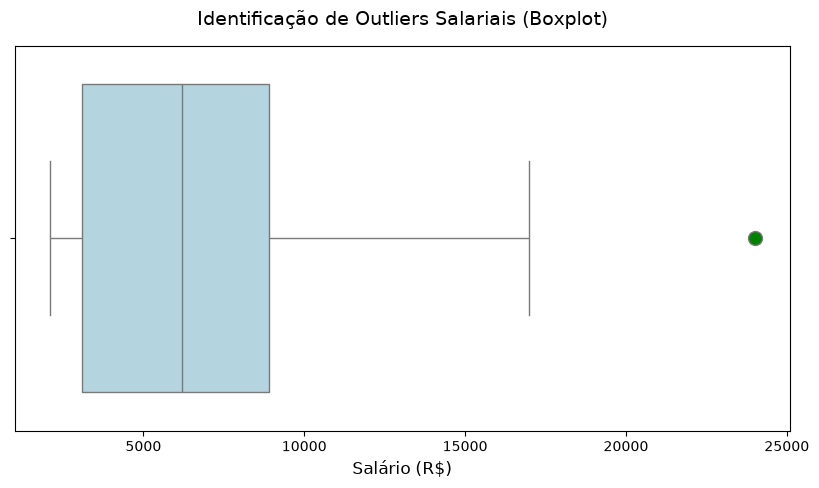

In [58]:
# Boxplot

# Configurar o tamanho da imagem
plt.figure(figsize=(10, 5))

# Criar o Boxplot na horizontal para facilitar a leitura
# flierprops - configura a bolinha do outlier
sns.boxplot(data=df_salarios, x='SALARIO', color='lightblue', flierprops={"marker": "o", "markerfacecolor": "green", "markersize": 10})

# adicionar títulos e rótulos limpos
plt.title('Identificação de Outliers Salariais (Boxplot)', fontsize=14, pad=15)
plt.xlabel('Salário (R$)', fontsize=12)

# Salva a imagem na pasta data
plt.savefig('../data/identificacao_outlier.png', dpi=300, bbox_inches='tight')

# Ajustar layout e exibir
plt.show()

In [59]:
# Filtrando salários muito acima ou muito abaixo da média
limite_superior = df_salarios['SALARIO'].mean() + (3 * df_salarios['SALARIO'].std())
outliers = df_salarios[df_salarios['SALARIO'] > limite_superior]

print(f"Quantidade de possíveis outliers: {len(outliers)}")
outliers.head()

Quantidade de possíveis outliers: 1


,ID_FUNCIONARIO,NOME_COMPLETO,SALARIO,DEPARTAMENTO,CARGO
95,100,Steven King,24000,Executive,President


Analise DF Geografia:

In [4]:
df_geografia.head()

,ID_FUNCIONARIO,NOME_COMPLETO,SALARIO,DEPARTAMENTO,CIDADE,ESTADO,PAIS,REGIAO
0,100,Steven King,24000,Executive,Seattle,Washington,United States of America,Americas
1,101,Neena Yang,17000,Executive,Seattle,Washington,United States of America,Americas
2,102,Lex Garcia,17000,Executive,Seattle,Washington,United States of America,Americas
3,103,Alexander James,9000,IT,Southlake,Texas,United States of America,Americas
4,104,Bruce Miller,6000,IT,Southlake,Texas,United States of America,Americas


In [ ]:
df_geografia.info() # indenficar o tipo de dado e se tem algum nulo

<class 'pandas.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ID_FUNCIONARIO  106 non-null    int64
 1   NOME_COMPLETO   106 non-null    str  
 2   SALARIO         106 non-null    int64
 3   DEPARTAMENTO    106 non-null    str  
 4   CIDADE          106 non-null    str  
 5   ESTADO          105 non-null    str  
 6   PAIS            106 non-null    str  
 7   REGIAO          106 non-null    str  
dtypes: int64(2), str(6)
memory usage: 6.8 KB


In [ ]:
# df_geografia.isnull().sum() # verificação de nulos
df_geografia[df_geografia.isnull().any(axis=1)] # Mostra a linha completa onde tem valor nulo 

,ID_FUNCIONARIO,NOME_COMPLETO,SALARIO,DEPARTAMENTO,CIDADE,ESTADO,PAIS,REGIAO
102,203,Susan Jacobs,6500,Human Resources,London,NaN,United Kingdom of Great Britain and Northern I...,Europe


In [14]:
id_duplicado = df_geografia.duplicated(subset=['ID_FUNCIONARIO']).sum()
print(f'Total de IDs duplicados: {id_duplicado}')

Nome_duplicado = df_geografia.duplicated(subset=['NOME_COMPLETO']).sum()
print(f'Total de nomes duplicados: {Nome_duplicado}')

Total de IDs duplicados: 0
Total de nomes duplicados: 0


In [17]:
df_geografia = df_geografia.dropna(subset=['ID_FUNCIONARIO', 'PAIS', 'REGIAO','CIDADE', 'ESTADO'])
df_geografia.info()

<class 'pandas.DataFrame'>
Index: 105 entries, 0 to 105
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ID_FUNCIONARIO  105 non-null    int64
 1   NOME_COMPLETO   105 non-null    str  
 2   SALARIO         105 non-null    int64
 3   DEPARTAMENTO    105 non-null    str  
 4   CIDADE          105 non-null    str  
 5   ESTADO          105 non-null    str  
 6   PAIS            105 non-null    str  
 7   REGIAO          105 non-null    str  
dtypes: int64(2), str(6)
memory usage: 7.4 KB


In [25]:
print("Distribuição por Região")
print(df_geografia['REGIAO'].value_counts()) # pega a coluna região e contabiliza cada linha repetida (regiões)
print()
print("Distribuição por País")
print(df_geografia['PAIS'].value_counts())
print()
print("Distribuição por Departamento")
print(df_geografia['DEPARTAMENTO'].value_counts())

Distribuição por Região
REGIAO
Americas    70
Europe      35
Name: count, dtype: int64

Distribuição por País
PAIS
United States of America                                68
United Kingdom of Great Britain and Northern Ireland    34
Canada                                                   2
Germany                                                  1
Name: count, dtype: int64

Distribuição por Departamento
DEPARTAMENTO
Shipping            45
Sales               34
Finance              6
Purchasing           6
IT                   5
Executive            3
Marketing            2
Accounting           2
Administration       1
Public Relations     1
Name: count, dtype: int64


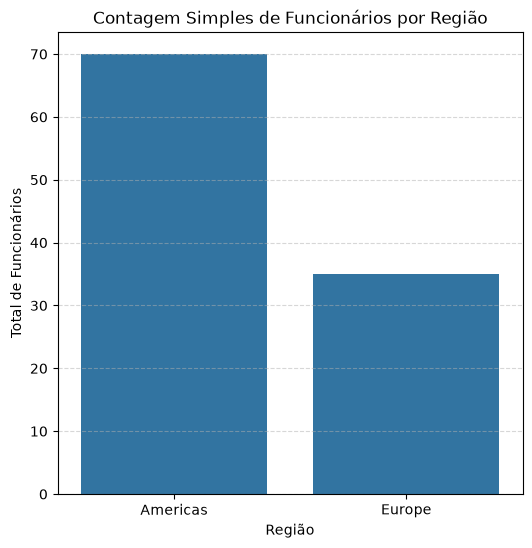

In [57]:
# Histograma

# Configuração do tamanho da figura
plt.figure(figsize=(6, 6))

# Gráfico de funcionários por Região
sns.countplot(
    data=df_geografia, 
    x='REGIAO', 
    order=df_geografia['REGIAO'].value_counts().index # count vai contar e o index vai pegar os nomes das linhas
)

# Título e rótulos
plt.title('Contagem Simples de Funcionários por Região')
plt.xlabel('Região')
plt.ylabel('Total de Funcionários')
plt.grid(axis='y', linestyle='--', alpha=0.5) # aplica linha de grade -- no eixo y com transparênia minima 0.5 

# Salva a imagem na pasta data
plt.savefig('../data/analise_agrupada_geografia.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# pd.merge - Cria um DF consolidado usando as duas tabelas
df_consolidado = pd.merge(
    df_geografia, 
    df_salarios, 
    on='ID_FUNCIONARIO', # chave de ligação entra as tabelas - chava primária
    how='left'
)

df_consolidado.head()

,ID_FUNCIONARIO,NOME_COMPLETO_x,SALARIO_x,DEPARTAMENTO_x,CIDADE,ESTADO,PAIS,REGIAO,NOME_COMPLETO_y,SALARIO_y,DEPARTAMENTO_y,CARGO
0,100,Steven King,24000,Executive,Seattle,Washington,United States of America,Americas,Steven King,24000,Executive,President
1,101,Neena Yang,17000,Executive,Seattle,Washington,United States of America,Americas,Neena Yang,17000,Executive,Administration Vice President
2,102,Lex Garcia,17000,Executive,Seattle,Washington,United States of America,Americas,Lex Garcia,17000,Executive,Administration Vice President
3,103,Alexander James,9000,IT,Southlake,Texas,United States of America,Americas,Alexander James,9000,IT,Programmer
4,104,Bruce Miller,6000,IT,Southlake,Texas,United States of America,Americas,Bruce Miller,6000,IT,Programmer


In [67]:
print(df_consolidado.columns.tolist())

['ID_FUNCIONARIO', 'NOME_COMPLETO_x', 'SALARIO_x', 'DEPARTAMENTO_x', 'CIDADE', 'ESTADO', 'PAIS', 'REGIAO', 'NOME_COMPLETO_y', 'SALARIO_y', 'DEPARTAMENTO_y', 'CARGO']


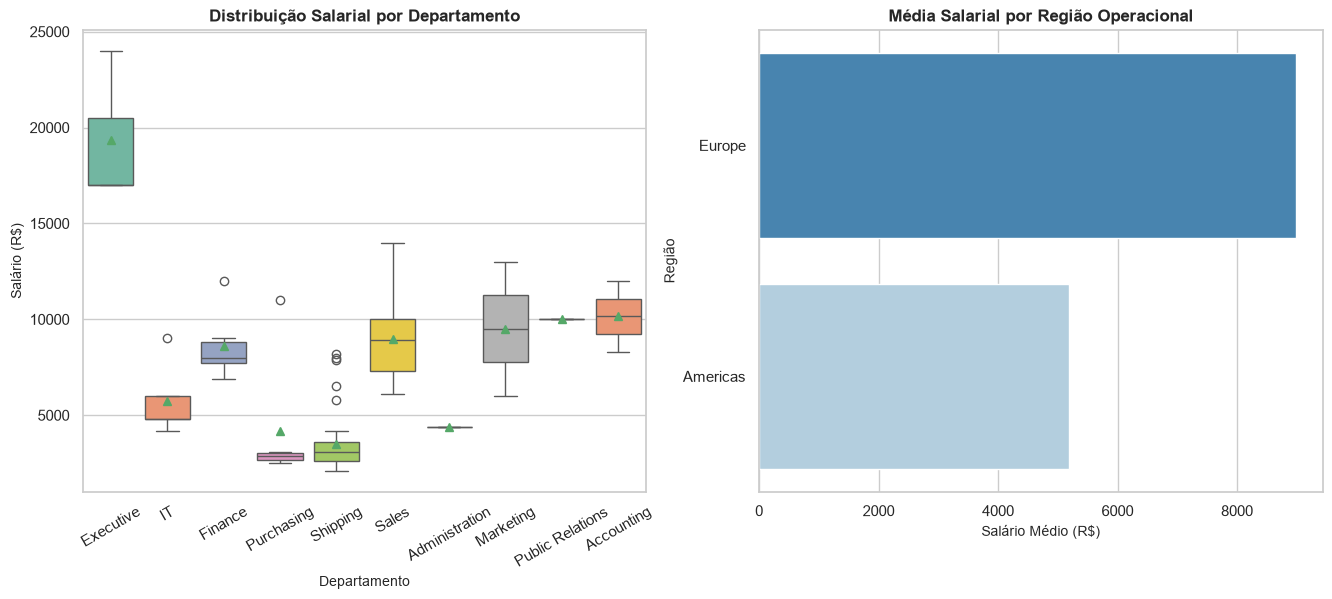

In [ ]:
# Configuração do estilo gráfico
sns.set_theme(style="whitegrid")

# Criação da figura com 1 linha e 2 colunas de eixos (ax1, ax2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Salários por departamento
sns.boxplot(
    data=df_consolidado,
    x="DEPARTAMENTO_x",
    y="SALARIO_x",
    hue="DEPARTAMENTO_x",
    ax=ax1,
    legend=False,
    palette="Set2",
    showmeans=True
)
ax1.set_title("Distribuição Salarial por Departamento", fontsize=12, fontweight="bold")
ax1.set_xlabel("Departamento", fontsize=10)
ax1.set_ylabel("Salário (R$)", fontsize=10)
ax1.tick_params(axis='x', rotation=30)

# Gráfico 2 - Média salarial por região 
df_media_regiao = (
    df_consolidado
    .groupby("REGIAO")["SALARIO_x"]
    .mean()
    .reset_index()
    .sort_values(by="SALARIO_x", ascending=False)
)

sns.barplot(
    data=df_media_regiao,
    x="SALARIO_x",
    y="REGIAO",
    hue="REGIAO",
    ax=ax2,
    legend=False,
    palette="Blues_r"
)
ax2.set_title("Média Salarial por Região Operacional", fontsize=12, fontweight="bold")
ax2.set_xlabel("Salário Médio (R$)", fontsize=10)
ax2.set_ylabel("Região", fontsize=10)

# salvamento da imagem e apresentação 
plt.savefig("../data/analise_avancada_salarios.png", dpi=300, bbox_inches='tight')
plt.show()